In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

In [2]:
TRAIN_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/train"
VAL_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/val"
TEST_DIR = r"E:/ML Portfolio Projects/11. Retinopathy_Detection/data/processed/test"

In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    brightness_range=[0.85, 1.15],
    shear_range=0.10,

    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1234 images belonging to 3 classes.


Found 265 images belonging to 3 classes.
Found 265 images belonging to 3 classes.


In [6]:
# Get training labels
train_labels = train_generator.classes

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to dictionary
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:")
print(class_weights_dict)

Class Weights:
{0: np.float64(0.7254556143445032), 1: np.float64(1.033500837520938), 2: np.float64(1.5291201982651796)}


In [7]:
print(train_generator.class_indices)

{'class_1': 0, 'class_2': 1, 'class_3': 2}


In [8]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [9]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [10]:
def categorical_focal_loss(alpha, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)

    def focal_loss(y_true, y_pred):
        y_pred = tf.clip_by_value(
            y_pred,
            tf.keras.backend.epsilon(),
            1.0 - tf.keras.backend.epsilon()
        )

        cross_entropy = -y_true * tf.math.log(y_pred)
        alpha_weight = y_true * alpha
        focal_weight = alpha_weight * tf.pow(1 - y_pred, gamma)
        loss = focal_weight * cross_entropy

        return tf.reduce_sum(loss, axis=1)

    return focal_loss

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.00003),

    loss=categorical_focal_loss(
        alpha=[0.20, 0.35, 0.45],
        gamma=2.0
    ),

    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

In [12]:
checkpoint = ModelCheckpoint(
    filepath=r"E:/ML Portfolio Projects/11. Retinopathy_Detection/models/efficientnetb0_focal_loss_best.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    class_weight=class_weights_dict,
    callbacks=[
        checkpoint,
        early_stop,
        lr_reduce
    ]
)

Epoch 1/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.3058 - loss: 0.1927 - precision: 0.3132 - recall: 0.1953
Epoch 1: val_loss improved from None to 0.12650, saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/efficientnetb0_focal_loss_best.keras

Epoch 1: finished saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/efficientnetb0_focal_loss_best.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 44s 480ms/step - accuracy: 0.3233 - loss: 0.1835 - precision: 0.3421 - recall: 0.1888 - val_accuracy: 0.4868 - val_loss: 0.1265 - val_precision: 0.3929 - val_recall: 0.0415 - learning_rate: 3.0000e-05
Epoch 2/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.4345 - loss: 0.1603 - precision: 0.4553 - recall: 0.2122
Epoch 2: val_loss improved from 0.12650 to 0.11208, saving model to E:/ML Portfolio Projects/11. Retinopathy_Detection/models/efficientnetb0_focal_loss_best.keras

Epoch 2: finished saving model to E:/ML Portfolio Projects/11. Retinopat

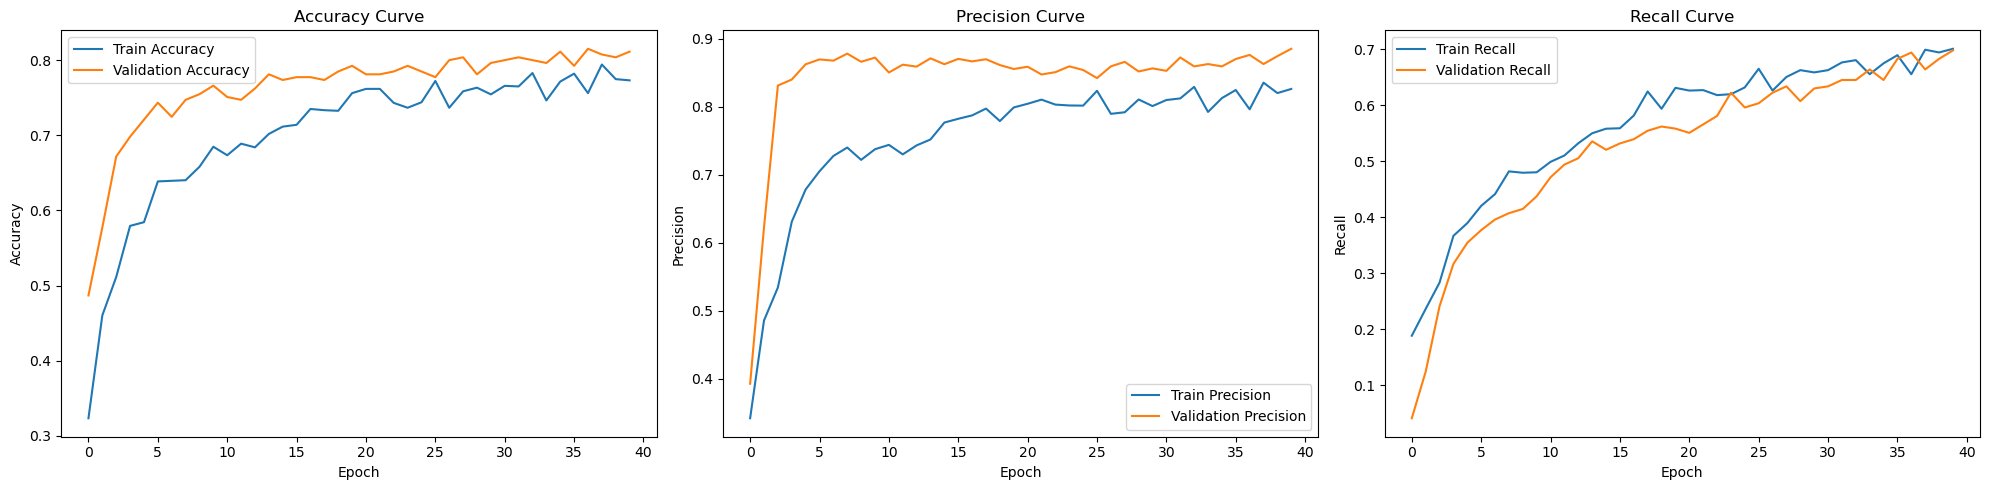

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ACCURACY
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')

axes[0].set_title("Accuracy Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()


# PRECISION
axes[1].plot(history.history['precision'], label='Train Precision')
axes[1].plot(history.history['val_precision'], label='Validation Precision')

axes[1].set_title("Precision Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Precision")
axes[1].legend()


# RECALL
axes[2].plot(history.history['recall'], label='Train Recall')
axes[2].plot(history.history['val_recall'], label='Validation Recall')

axes[2].set_title("Recall Curve")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Recall")
axes[2].legend()


plt.tight_layout()
plt.show()

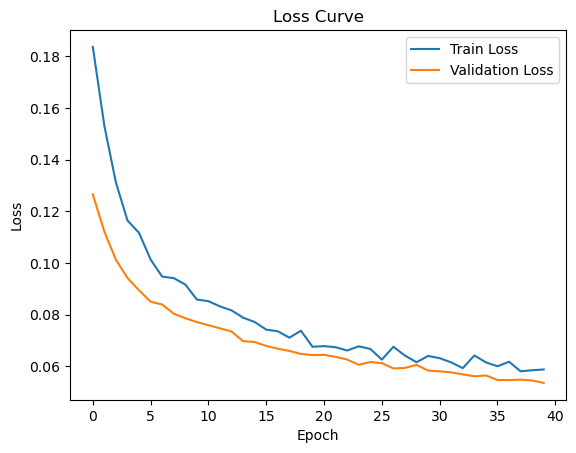

In [15]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [16]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 314ms/step - accuracy: 0.8302 - loss: 0.0460 - precision: 0.8857 - recall: 0.7019
Test Loss: 0.046005889773368835
Test Accuracy: 0.8301886916160583
Test Precision: 0.8857142925262451
Test Recall: 0.701886773109436


In [17]:
# Predict probabilities
y_pred_probs = model.predict(test_generator)

# Convert probabilities to predicted classes
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 345ms/step


In [18]:
print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

              precision    recall  f1-score   support

     class_1       0.99      0.93      0.96       122
     class_2       0.77      0.72      0.74        86
     class_3       0.64      0.79      0.71        57

    accuracy                           0.83       265
   macro avg       0.80      0.81      0.80       265
weighted avg       0.84      0.83      0.83       265



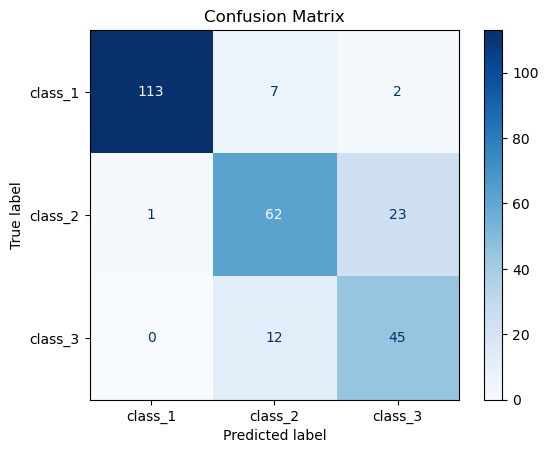

In [19]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_generator.class_indices.keys()
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")

plt.show()

In [20]:
# Convert labels to one-hot
y_true_bin = label_binarize(y_true, classes=[0,1,2])

# Compute ROC-AUC
roc_auc = roc_auc_score(
    y_true_bin,
    y_pred_probs,
    multi_class='ovr'
)

print("Multiclass ROC-AUC:", roc_auc)

Multiclass ROC-AUC: 0.954390264978558
